In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
data = pd.read_csv("drive/Shareddrives/STATS FINAL/data/cleaned_origional_data.csv", index_col=0)
data = data.drop('Month', axis=1)
data['date'] = pd.to_datetime(data['date'])
data['Raw_Size']   = np.log(data['mkt_val'])              # Log Market Cap
data['Raw_BM']     = data['equity'] / data['mkt_val']     # Book-to-Market Ratio
data['Raw_OpLev']  = data['op_profit'] / data['assets']   # Operating Profitability
data['Raw_FinLev'] = data['liab'] / data['assets']        # Financial Leverage
data['Raw_EP']     = data['op_profit'] / data['mkt_val']  # Earnings-to-Price Ratio

# Sort is required for shift/rolling operations
data = data.sort_values(['code', 'date'])

# Reversal: Return from the previous month (Lag 1)
data['Raw_Rev'] = data.groupby('code')['ret'].shift(1)

# Asset Growth: Percentage change in assets
data['Raw_AG'] = data.groupby('code')['assets'].pct_change(periods=12)

# Momentum: 12-month rolling average return
data['Raw_Mom'] = data.groupby('code')['ret'].rolling(12, min_periods=6).mean().reset_index(level=0, drop=True)


Mounted at /content/drive


/tmp/ipython-input-1647734574.py:33: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  data['Raw_AG'] = data.groupby('code')['assets'].pct_change(periods=12)


In [ ]:

# Map raw variables to their ranked counterparts
input_vars = {
    'Raw_Size': 'Rank_Size',
    'Raw_BM': 'Rank_BM',
    'Raw_OpLev': 'Rank_OpLev',
    'Raw_FinLev': 'Rank_FinLev',
    'Raw_EP': 'Rank_EP',
    'Raw_Mom': 'Rank_Mom',
    'Raw_Rev': 'Rank_Rev',
    'Raw_AG': 'Rank_AG'
}

# Transform raw values into cross-sectional percentile ranks (0 to 1)
# This normalizes data across different time periods
for raw_col, rank_col in input_vars.items():
    data[rank_col] = data.groupby('date')[raw_col].rank(pct=True)

final_cols = ['date', 'code', 'y'] + list(input_vars.values())

# Drop NaNs created by lag and rolling window operations
model_data = data[final_cols].dropna()

print(f"Feature engineering complete. Total independent variables: {len(input_vars)}")
print(model_data.head())

Feature engineering complete. Total independent variables: 8
            date  code         y  Rank_Size   Rank_BM  Rank_OpLev  \
27573 2011-09-01     1 -0.050942   0.981123  0.658379    0.206262   
31184 2011-10-01     1  0.049498   0.981575  0.659143    0.205896   
32828 2011-11-01     1 -0.084032   0.980148  0.676362    0.205448   
36014 2011-12-01     1  0.002287   0.982480  0.606731    0.206547   
36295 2012-01-01     1  0.064480   0.982379  0.795154    0.184581   

       Rank_FinLev   Rank_EP  Rank_Mom  Rank_Rev   Rank_AG  
27573     0.982965  0.952578  0.703523  0.553967  0.822508  
31184     0.982497  0.951175  0.658668  0.874136  0.822024  
32828     0.983380  0.953370  0.777505  0.602493  0.822876  
36014     0.983864  0.940065  0.887488  0.312731  0.822357  
36295     0.979295  0.944053  0.929466  0.941748  0.949597  


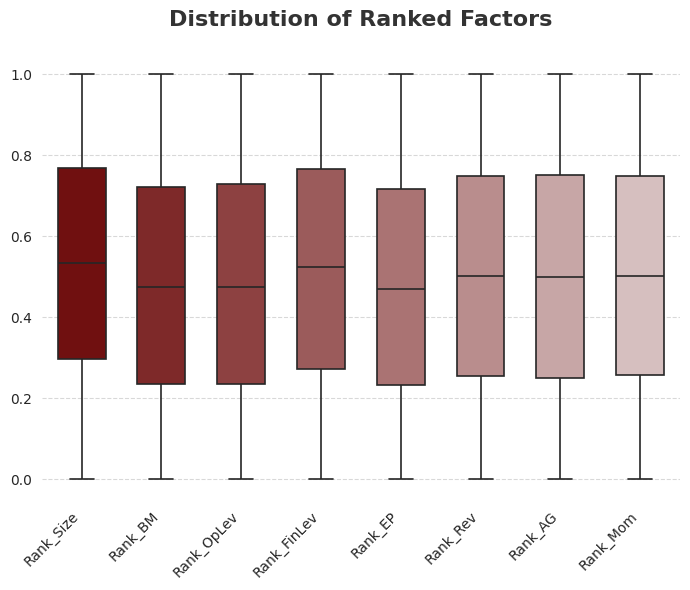

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
cols_to_plot = [
    'Rank_Size', 'Rank_BM', 'Rank_OpLev', 'Rank_FinLev',
    'Rank_EP', 'Rank_Rev', 'Rank_AG', 'Rank_Mom'
]

plot_data = model_data[cols_to_plot].dropna().copy()

sns.set_style("whitegrid")

custom_palette = sns.light_palette("maroon", n_colors=len(cols_to_plot) + 2, reverse=True)
final_palette = custom_palette[:len(cols_to_plot)]

plt.figure(figsize=(7, 6))

ax = sns.boxplot(
    data=plot_data,
    palette=final_palette,
    width=0.6,
    linewidth=1.2,
    fliersize=2,
    flierprops={"marker": "o", "markerfacecolor": "gray", "markeredgewidth": 0, "alpha": 0.6}
)

plt.title('Distribution of Ranked Factors', fontsize=16, fontweight='bold', pad=20, color='#333333')


plt.xticks(rotation=45, ha='right', fontsize=10)


plt.yticks(fontsize=10)

ax.yaxis.grid(True, linestyle='--', which='major', color='gray', alpha=0.3)
ax.xaxis.grid(False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

In [ ]:
df = model_data

In [ ]:
df['code'] = df['code'].astype(str).str.zfill(6)
df['date'] = pd.to_datetime(df['date'])
display(df)

,date,code,y,Rank_Size,Rank_BM,Rank_OpLev,Rank_FinLev,Rank_EP,Rank_Mom,Rank_Rev,Rank_AG
27573,2011-09-01,000001,-0.050942,0.981123,0.658379,0.206262,0.982965,0.952578,0.703523,0.553967,0.822508
31184,2011-10-01,000001,0.049498,0.981575,0.659143,0.205896,0.982497,0.951175,0.658668,0.874136,0.822024
32828,2011-11-01,000001,-0.084032,0.980148,0.676362,0.205448,0.983380,0.953370,0.777505,0.602493,0.822876
36014,2011-12-01,000001,0.002287,0.982480,0.606731,0.206547,0.983864,0.940065,0.887488,0.312731,0.822357
36295,2012-01-01,000001,0.064480,0.982379,0.795154,0.184581,0.979295,0.944053,0.929466,0.941748,0.949597
...,...,...,...,...,...,...,...,...,...,...,...
451588,2022-11-01,871981,0.016883,0.009613,0.940888,0.709288,0.440262,0.934342,0.001481,0.068951,0.965247
456494,2022-12-01,871981,-0.056194,0.027840,0.771185,0.705894,0.440244,0.830319,0.004990,0.278689,0.965247
446693,2022-10-01,872925,0.022839,0.008608,0.827834,0.874129,0.056786,0.892806,0.260326,0.709704,0.992351
451585,2022-11-01,872925,-0.017570,0.015136,0.683371,0.872954,0.056669,0.811822,0.126507,0.513441,0.992377


In [ ]:
# Step 2.1.1: Select dependent and independent variables
# Select dependent variable y
y = df["y"]

# Select independent variables X (all Rank_* columns)
X_cols = [col for col in df.columns if col.startswith("Rank_")]
X = df[X_cols]

print("Independent variables:", X_cols)
X.head()

Independent variables: ['Rank_Size', 'Rank_BM', 'Rank_OpLev', 'Rank_FinLev', 'Rank_EP', 'Rank_Mom', 'Rank_Rev', 'Rank_AG']


,Rank_Size,Rank_BM,Rank_OpLev,Rank_FinLev,Rank_EP,Rank_Mom,Rank_Rev,Rank_AG
27573,0.981123,0.658379,0.206262,0.982965,0.952578,0.703523,0.553967,0.822508
31184,0.981575,0.659143,0.205896,0.982497,0.951175,0.658668,0.874136,0.822024
32828,0.980148,0.676362,0.205448,0.983380,0.953370,0.777505,0.602493,0.822876
36014,0.982480,0.606731,0.206547,0.983864,0.940065,0.887488,0.312731,0.822357
36295,0.982379,0.795154,0.184581,0.979295,0.944053,0.929466,0.941748,0.949597


In [ ]:
# Step 2.1.2: Split data into training and testing sets

from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test set
    shuffle=True,       # shuffle to remove ordering
    random_state=42     # ensure reproducibility
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (321582, 8)
y_train shape: (321582,)
X_test shape: (80396, 8)
y_test shape: (80396,)


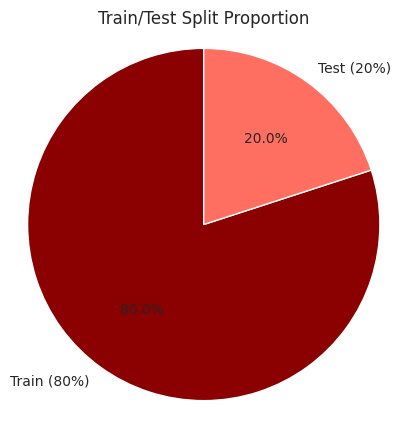

In [ ]:
import matplotlib.pyplot as plt

# Define train/test sizes directly from your split
train_size = len(X_train)
test_size = len(X_test)

sizes = [train_size, test_size]
labels = ['Train (80%)', 'Test (20%)']
colors = ['#8B0000', '#FF6F61']   # wine red + coral red

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Train/Test Split Proportion')
plt.axis('equal')
plt.show()

In [ ]:
# Step 2.1.3: Create training and testing DataFrames for convenient analysis

train_df = X_train.copy()
train_df["y"] = y_train

test_df = X_test.copy()
test_df["y"] = y_test

train_df.head()

,Rank_Size,Rank_BM,Rank_OpLev,Rank_FinLev,Rank_EP,Rank_Mom,Rank_Rev,Rank_AG,y
181531,0.244009,0.234205,0.714597,0.508351,0.510167,0.278730,0.901961,0.764817,-0.134666
347671,0.329954,0.456918,0.841865,0.317283,0.752408,0.487532,0.256541,0.846154,-0.046847
409960,0.293794,0.212879,0.443126,0.643720,0.329379,0.917392,0.175653,0.085071,0.054168
354125,0.795379,0.085517,0.841115,0.507384,0.381134,0.715198,0.751144,0.951872,0.142800
262398,0.493143,0.154492,0.942065,0.732438,0.804086,0.989486,0.336552,0.694220,0.328890


In [ ]:
# Step 2.2.1: Compute VIF for rank variables in the training set

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use only the rank columns from the training set
X_train_vif = X_train.copy()

# Create a DataFrame to store VIF values
vif_data = pd.DataFrame()
vif_data["variable"] = X_train_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_train_vif.values, i)
    for i in range(X_train_vif.shape[1])
]

# Sort by VIF descending for easier inspection
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
vif_data

,variable,VIF
0,Rank_EP,16.431484
1,Rank_OpLev,13.519095
2,Rank_BM,5.645044
3,Rank_Size,5.471634
4,Rank_FinLev,5.104799
5,Rank_AG,4.614814
6,Rank_Mom,4.404693
7,Rank_Rev,3.950393


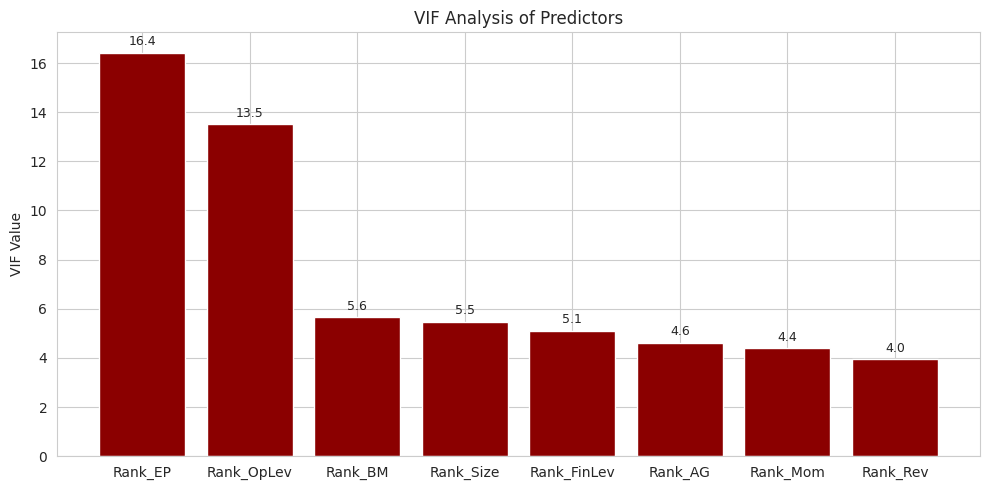

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract variables and VIF values
vars_vif = vif_data["variable"]
vif_vals = vif_data["VIF"]

# Sort for nicer display (optional)
order = np.argsort(vif_vals.values)[::-1]
vars_sorted = vars_vif.values[order]
vif_sorted = vif_vals.values[order]

wine_red = "#8B0000"

plt.figure(figsize=(10,5))
bars = plt.bar(vars_sorted, vif_sorted, color=wine_red)

plt.ylabel("VIF Value")
plt.title("VIF Analysis of Predictors")

# Add value labels
for bar, val in zip(bars, vif_sorted):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        val + 0.3,
        f"{val:.1f}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [ ]:
# Step 2.2.2: BIC-based backward elimination
import statsmodels.api as sm
import numpy as np

def backward_elimination_bic(X, y):
    """
    Perform backward elimination using BIC.
    X: DataFrame of independent variables
    y: Series of dependent variable
    Returns the model with the lowest BIC and selected features.
    """
    X_be = X.copy()
    best_bic = np.inf
    best_model = None
    best_vars = X_be.columns.tolist()

    while True:
        # Fit model with constant
        X_with_const = sm.add_constant(X_be)
        model = sm.OLS(y, X_with_const).fit()
        current_bic = model.bic

        # If BIC improved, update the best model
        if current_bic < best_bic:
            best_bic = current_bic
            best_model = model
            best_vars = X_be.columns.tolist()
        else:
            break  # stop if BIC no longer improves

        # Try removing each variable one-by-one and compute BIC
        bics = {}
        for col in X_be.columns:
            X_temp = X_be.drop(columns=[col])
            model_temp = sm.OLS(y, sm.add_constant(X_temp)).fit()
            bics[col] = model_temp.bic

        # Find variable whose removal gives lowest BIC
        var_to_remove = min(bics, key=bics.get)
        min_bic_after_removal = bics[var_to_remove]

        # If removing improves BIC → remove and continue
        if min_bic_after_removal < best_bic:
            X_be = X_be.drop(columns=[var_to_remove])
        else:
            break  # no further improvement, stop

    return best_model, best_vars, best_bic

In [ ]:
bic_model, bic_selected_vars, bic_value = backward_elimination_bic(X_train, y_train)

print("Selected variables by BIC:")
print(bic_selected_vars)
print("\nBest BIC:", bic_value)


Selected variables by BIC:
['Rank_Size', 'Rank_BM', 'Rank_OpLev', 'Rank_FinLev', 'Rank_Mom', 'Rank_Rev', 'Rank_AG']

Best BIC: -343758.22525331285


In [ ]:
# Step 2.3 - A: Prepare final datasets using BIC-selected variables

# Use BIC-selected variables as final variable set
final_vars = bic_selected_vars

# Subset training and test sets
X_train_final = X_train[final_vars].copy()
X_test_final = X_test[final_vars].copy()

print("Final variables for the model:", final_vars)
print("Training shape:", X_train_final.shape)
print("Test shape:", X_test_final.shape)

Final variables for the model: ['Rank_Size', 'Rank_BM', 'Rank_OpLev', 'Rank_FinLev', 'Rank_Mom', 'Rank_Rev', 'Rank_AG']
Training shape: (321582, 7)
Test shape: (80396, 7)


In [ ]:
# Step 2.3 - B: Add constant to training set

import statsmodels.api as sm

X_train_model = sm.add_constant(X_train_final)
y_train_model = y_train

X_train_model.head()

,const,Rank_Size,Rank_BM,Rank_OpLev,Rank_FinLev,Rank_Mom,Rank_Rev,Rank_AG
181531,1.0,0.244009,0.234205,0.714597,0.508351,0.278730,0.901961,0.764817
347671,1.0,0.329954,0.456918,0.841865,0.317283,0.487532,0.256541,0.846154
409960,1.0,0.293794,0.212879,0.443126,0.643720,0.917392,0.175653,0.085071
354125,1.0,0.795379,0.085517,0.841115,0.507384,0.715198,0.751144,0.951872
262398,1.0,0.493143,0.154492,0.942065,0.732438,0.989486,0.336552,0.694220


In [ ]:
# Step 2.3 - C: Fit OLS model with robust (HC1) standard errors

model = sm.OLS(y_train_model, X_train_model).fit(cov_type="HC1")

# Display full regression summary
model_summary = model.summary()
model_summary

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     1664.
Date:                Sun, 07 Dec 2025   Prob (F-statistic):               0.00
Time:                        05:37:45   Log-Likelihood:             1.7193e+05
No. Observations:              321582   AIC:                        -3.438e+05
Df Residuals:                  321574   BIC:                        -3.438e+05
Df Model:                           7                                         
Covariance Type:                  HC1                                         
===============================================================================
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -0.0142      0.001    -12.754      0.000      -0.016      -0.012
Rank_Size       0.0098      0.001     10.386      0.000       0.008       0.012
Rank_BM        -0.0116      0.001    -12.884      0.000      -0.013      -0.010
Rank_OpLev     -0.0131      0.001    -11.647      0.000      -0.015      -0.011
Rank_FinLev    -0.0091      0.001     -8.150      0.000      -0.011      -0.007
Rank_Mom        0.1125      0.001    101.800      0.000       0.110       0.115
Rank_Rev       -0.0384      0.001    -39.618      0.000      -0.040      -0.036
Rank_AG        -0.0061      0.001     -5.909      0.000      -0.008      -0.004
==============================================================================
Omnibus:                   334385.062   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        657896381.316
Skew:                           4.074   Prob(JB):                         0.00
Kurtosis:                     224.434   Cond. No.                         10.2
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

In [ ]:
# Step 2.3 - D: Create a clean coefficient table for PPT use

import pandas as pd

coef_table = pd.DataFrame({
    "Coefficient": model.params,
    "Std_Error_HC1": model.bse,
    "t_value": model.tvalues,
    "p_value": model.pvalues
})

coef_table

,Coefficient,Std_Error_HC1,t_value,p_value
const,-0.014177,0.001112,-12.753981,2.962225e-37
Rank_Size,0.009840,0.000947,10.385974,2.872234e-25
Rank_BM,-0.011582,0.000899,-12.883728,5.558409e-38
Rank_OpLev,-0.013126,0.001127,-11.646793,2.382572e-31
Rank_FinLev,-0.009104,0.001117,-8.150479,3.624842e-16
Rank_Mom,0.112550,0.001106,101.800282,0.000000e+00
Rank_Rev,-0.038381,0.000969,-39.618178,0.000000e+00
Rank_AG,-0.006122,0.001036,-5.909023,3.441430e-09


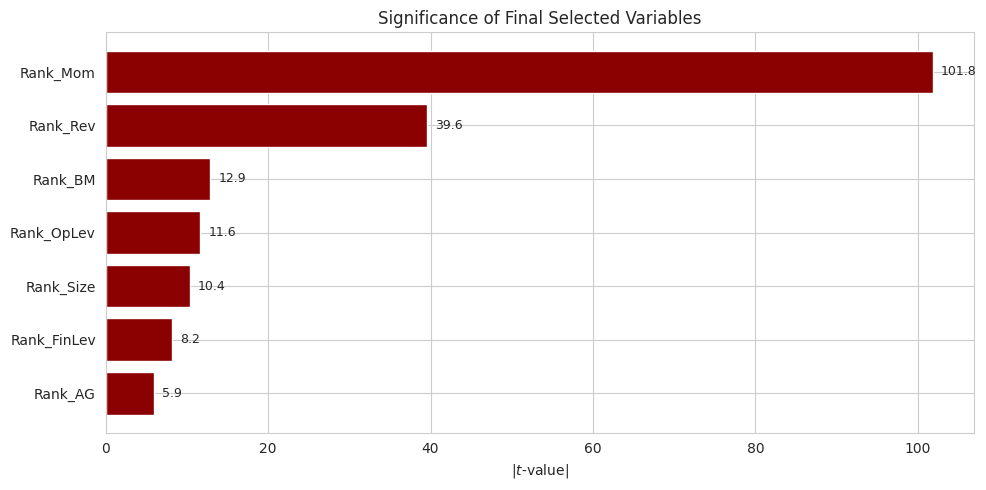

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tvals = coef_table['t_value'].abs().iloc[1:]   # skip const
vars_ = coef_table.index[1:]

order = np.argsort(tvals.values)
tvals_sorted = tvals.values[order]
vars_sorted = vars_[order]

wine_red = '#8B0000'

plt.figure(figsize=(10,5))
bars = plt.barh(vars_sorted, tvals_sorted, color=wine_red)

plt.xlabel(r'$|t\text{-value}|$')
plt.title('Significance of Final Selected Variables')

for bar, val in zip(bars, tvals_sorted):
    plt.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.1f}',
        va='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# Results Interpretation

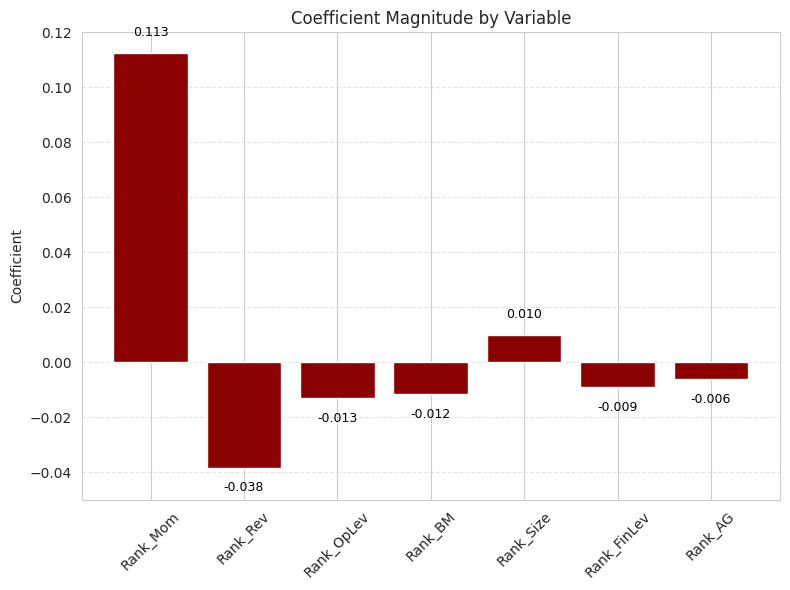

,Variable,Coefficient,Std_Error,T_value,P_value,abs_coef
5,Rank_Mom,0.112550,0.001106,101.800282,0.000000e+00,0.112550
6,Rank_Rev,-0.038381,0.000969,-39.618178,0.000000e+00,0.038381
3,Rank_OpLev,-0.013126,0.001127,-11.646793,2.382572e-31,0.013126
2,Rank_BM,-0.011582,0.000899,-12.883728,5.558409e-38,0.011582
1,Rank_Size,0.009840,0.000947,10.385974,2.872234e-25,0.009840
4,Rank_FinLev,-0.009104,0.001117,-8.150479,3.624842e-16,0.009104
7,Rank_AG,-0.006122,0.001036,-5.909023,3.441430e-09,0.006122


In [ ]:
# Clean table
coef_table = pd.DataFrame({
    "Variable": model.params.index,
    "Coefficient": model.params.values,
    "Std_Error": model.bse.values,
    "T_value": model.tvalues.values,
    "P_value": model.pvalues.values
})

# Drop constant
coef_table = coef_table[coef_table["Variable"] != "const"]

# Sort by absolute value
coef_table["abs_coef"] = coef_table["Coefficient"].abs()
coef_table = coef_table.sort_values(by="abs_coef", ascending=False)

# Plot
import matplotlib.pyplot as plt
import numpy as np

wine_red = "#8B0000"

plt.figure(figsize=(8,6))
bars = plt.bar(
    coef_table["Variable"],
    coef_table["Coefficient"],
    color=wine_red
)

for bar, value in zip(bars, coef_table["Coefficient"]):
    height = bar.get_height()

    if value >= 0:
        y = height + 0.005
        va = "bottom"
    else:
        y = height - 0.005
        va = "top"

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f"{value:.3f}",
        ha="center",
        va=va,
        fontsize=9,
        color="black"
    )

# --- Set consistent y-axis limits and tick spacing ---
plt.ylim(-0.05, 0.12)                           # guaranteed space above/below labels
plt.yticks(np.arange(-0.04, 0.13, 0.02))         # ticks every 0.02: -0.04…0.12

# --- Formatting ---
plt.xticks(rotation=45)
plt.ylabel("Coefficient")
plt.title("Coefficient Magnitude by Variable")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

coef_table

The results show that Momentum has the strongest effect on monthly excess return. If a stock moves from the bottom rank to the top rank in Momentum, its expected excess return increases by roughly 11% in that month. Reversal has the largest negative effect, which aligns with the idea that short-term price reversals can reduce return. Book-to-Market and leverage measures also show negative signs, which suggests that growth stocks and low-leverage firms performed better during our sample period. Size and asset growth have smaller positive effects.

# Prediction Performance

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np
import statsmodels.api as sm

# Train predictions
y_pred_train = model.predict(X_train_model)

# Test predictions
X_test_model = sm.add_constant(X_test_final)
y_pred_test = model.predict(X_test_model)

# RMSE calculation
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("Train RMSE:", rmse_train)
print("Test RMSE:", rmse_test)

Train RMSE: 0.14176618570807833
Test RMSE: 0.1420888793286457


The train RMSE is 0.1417 and the test RMSE is 0.1420. The values are almost the same, which means the model does not overfit. It performs in a stable way on new data, even though monthly returns are very noisy. The small difference between the train and test errors shows that the ranking transformation reduces time effects and helps the model generalize.

# Sensitivity Analysis

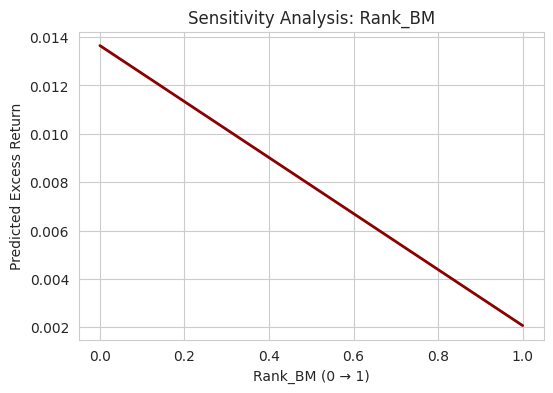

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Choose the variable for sensitivity test
var = "Rank_BM"

# Make values from 0 to 1 (100 points)
grid = np.linspace(0, 1, 100)

df_sen = pd.DataFrame({col: np.full_like(grid, 0.5, dtype=float)
                       for col in final_vars})

# Vary only the selected variable
df_sen[var] = grid

# Add constant column
df_sen["const"] = 1.0

# Reorder to match model parameters
df_sen = df_sen[model.params.index]

# Predict
y_sen = model.predict(df_sen)

# Plot
wine_red = "#8B0000"
plt.figure(figsize=(6,4))
plt.plot(grid, y_sen, linewidth=2, color=wine_red)
plt.xlabel("Rank_BM (0 → 1)")
plt.ylabel("Predicted Excess Return")
plt.title("Sensitivity Analysis: Rank_BM")
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd

target_vars = ["Rank_Size", "Rank_BM", "Rank_OpLev", "Rank_FinLev", "Rank_Mom", "Rank_Rev", "Rank_AG"]

grid = np.linspace(0, 1, 11)

results_dict = {"Input_Value (0to1)": grid}

for var in target_vars:
    df_temp = pd.DataFrame({col: np.full_like(grid, 0.5, dtype=float) for col in final_vars})

    df_temp[var] = grid

    df_temp["const"] = 1.0

    df_temp = df_temp[model.params.index]

    results_dict[f"Pred_Y_by_{var}"] = model.predict(df_temp)

df_sensitivity_detail = pd.DataFrame(results_dict)


summary_data = []
for var in target_vars:
    col_name = f"Pred_Y_by_{var}"
    y_min = df_sensitivity_detail[col_name].iloc[0]
    y_max = df_sensitivity_detail[col_name].iloc[-1]
    impact = y_max - y_min

    summary_data.append({
        "Variable": var,
        "Y_at_Min(0)": y_min,
        "Y_at_Max(1)": y_max,
        "Total_Impact (Range)": impact,
        "Abs_Impact": abs(impact)
    })

df_sensitivity_summary = pd.DataFrame(summary_data)


df_sensitivity_summary.sort_values("Abs_Impact", ascending=False, inplace=True)
df_sensitivity_summary.drop(columns=["Abs_Impact"], inplace=True)

print("Sensitivity Analysis")
print(df_sensitivity_summary.round(4))


Sensitivity Analysis
      Variable  Y_at_Min(0)  Y_at_Max(1)  Total_Impact (Range)
4     Rank_Mom      -0.0484       0.0641                0.1125
5     Rank_Rev       0.0271      -0.0113               -0.0384
2   Rank_OpLev       0.0144       0.0013               -0.0131
1      Rank_BM       0.0137       0.0021               -0.0116
0    Rank_Size       0.0029       0.0128                0.0098
3  Rank_FinLev       0.0124       0.0033               -0.0091
6      Rank_AG       0.0109       0.0048               -0.0061


In this analysis, Rank_BM increases from 0 to 1 while all other factors stay at their median value of 0.5. The predicted excess return decreases almost linearly from about 1.3% to 0. This means that higher Book-to-Market stocks earn lower excess returns in our sample. In other words, growth stocks outperform value stocks in the Chinese market during 2011–2022. The curve is close to a straight line, which supports using a linear model on the ranked factors.

# Model Limitations

Our model offers a simple way to explain cross-sectional monthly excess returns using seven ranking signals, but it has several limitations.

### 1. Low R² due to noise

The adjusted R² is about 0.052. This is common in asset pricing because monthly returns include a large amount of random noise from earnings news, policy changes, and investor sentiment. Even standard factor models usually explain only a small part of return differences at a monthly frequency. The low R² does not mean the model is useless, but it shows that short-horizon return prediction has limited power.

### 2. Linear form may miss nonlinear patterns

The model assumes a linear relationship between ranked factors and returns. This ignores potential nonlinear effects, especially at extreme ranks (e.g., top momentum deciles often behave differently than mid-range values). As a result, the coefficient captures the average slope, but may not reflect threshold behavior.

### 3. Possible omitted variables

We only include seven firm-level factors. We do not control for industry differences, volatility, or investment factor. If these omitted variables are correlated with included factors (e.g., high BM firms clustering in specific industries), the coefficients may capture industry effects rather than pure factor premiums.

### 4. No time-period structure

We use a pooled model from 2011 to 2022, which assumes stable relationships over time. However, the Chinese market experienced several regime changes, such as the 2015 crash and the 2020 technology rally. The negative value effect may reflect certain sub-periods rather than a persistent pattern.